# 7장 실습 — 기준 정책: 행동 복제와 강화학습

2부가 데이터셋 `data/cell_v1/` 과 정규화 통계를 넘겼다. 3부는 그 위에 정책을 세운다. 이 노트북은 **두 기준 정책**을 같은 자로 잰다.

1. **행동 복제** — `data/cell_v1/` 의 128판을 흉내 낸다. 환경과 한 번도 상호작용하지 않는다
2. **강화학습** — 1장의 PPO 에 4장의 정규화를 입혀 환경에서 25만 스텝을 굴린다. 시연은 쓰지 않는다

그리고 둘을 잇는 셋째 후보를 하나 더 잰다. **복제로 시작해 강화학습으로 이어 학습**하는 것이다. 전문가가 없는 축 — 주기 — 에서 강화학습이 무엇을 더하는지, 그 대가가 무엇인지를 본다.

평가는 모두 **평균 행동**으로 한다. 1장의 강화학습 기준선은 행동을 표본 추출해 쟀으므로 수가 조금 다를 수 있다.

끝에서 `policy/bc_v1.pt`, `policy/rl_v1.pt` 와 두 기준선의 수를 적은 `policy/baseline.json` 을 남긴다. 3부의 나머지 두 장과 4~6부가 이 두 수를 기준으로 삼는다.

`pyarrow` 를 쓴다(Colab 에는 기본으로 깔려 있다).

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


## 두 기준 정책과 이어 학습

세 후보의 학습 방법을 적는다. 신경망 구조는 셋 모두 1장의 것(64-64 tanh)이다.

| 후보 | 학습 신호 | 환경 상호작용 | 시연 |
|---|---|---|---|
| 행동 복제 | 시연의 전문가 명령 | 0 | 128판 |
| 강화학습 | 1장의 보상 | 25만 스텝 | 0 |
| 복제 → 강화학습 | 복제로 시작, 1장의 보상으로 이어 학습 | 10만 스텝 | 128판 |

이어 학습은 탐색 잡음을 작게(표준편차 e^−1.5 ≈ 0.22) 시작하고 학습률을 1/10로 낮춘다. 복제가 배운 것을 첫 갱신에서 잃지 않게 하기 위해서다.

In [8]:
def ppo(budget=250_000, seed=0, init=None, ls=None, lr=3e-3,
        n=16, T=32):
    """1장의 PPO + 4장의 정규화 — init 을 주면 이어서 학습"""
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC() if init is None else init
    if ls is not None:
        ac.ls.data[:] = ls
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = nz(env.obs())
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = nz(env.obs())
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [9]:
SEEDS = (0, 1, 2)
EV = dict(n=150, reps=3)                     # 1장의 평가 예산
RES, COST, LOG, NETS = {}, {}, [], {}


def measure(name, net, s):
    for c in COND:
        rows = rollout(pol(net), c, tag=s, ver=name, **EV)
        LOG.extend(rows)
        RES.setdefault((name, c), []).append(
            (rate(rows), cycle(rows)))


XN = nz(XS)
for s in SEEDS:
    t0 = time.time()
    b = bc(XN, YS, seed=s)
    COST.setdefault("행동 복제", []).append(time.time() - t0)
    NETS[("행동 복제", s)] = b
    measure("행동 복제", b, s)

    t0 = time.time()
    r = ppo(seed=s)
    COST.setdefault("강화학습", []).append(time.time() - t0)
    NETS[("강화학습", s)] = r
    measure("강화학습", r, s)

    t0 = time.time()
    f = ppo(budget=100_000, seed=s, init=copy.deepcopy(b), ls=-1.5,
            lr=3e-4)
    COST.setdefault("복제 → 강화학습", []).append(time.time() - t0)
    NETS[("복제 → 강화학습", s)] = f
    measure("복제 → 강화학습", f, s)
    print(f"시드 {s} 끝", flush=True)

시드 0 끝


시드 1 끝


시드 2 끝


In [10]:
CAND = ["행동 복제", "강화학습", "복제 → 강화학습"]


def cell(v):
    return f"{np.mean(v):.3f} [{min(v):.2f}, {max(v):.2f}]"


print(pad("후보", 16) + pad("명목", 20, True)
      + pad("배포", 20, True)
      + pad("주기 명목", 10, True) + pad("주기 배포", 10, True)
      + pad("학습 s", 8, True))
for k in CAND:
    sn = [x[0] for x in RES[(k, "명목")]]
    sd = [x[0] for x in RES[(k, "배포")]]
    cn = np.mean([x[1] for x in RES[(k, "명목")]])
    cd = np.mean([x[1] for x in RES[(k, "배포")]])
    print(pad(k, 16) + pad(cell(sn), 20, True)
          + pad(cell(sd), 20, True) + pad(f"{cn:.0f}", 10, True)
          + pad(f"{cd:.0f}", 10, True)
          + pad(f"{np.mean(COST[k]):.0f}", 8, True))

후보                            명목                배포 주기 명목 주기 배포  학습 s
행동 복제         1.000 [1.00, 1.00]  0.947 [0.89, 0.98]        52        47       5
강화학습          0.997 [1.00, 1.00]  0.508 [0.42, 0.68]        19        23      75
복제 → 강화학습   0.996 [0.99, 1.00]  0.804 [0.63, 0.90]        20        26      31


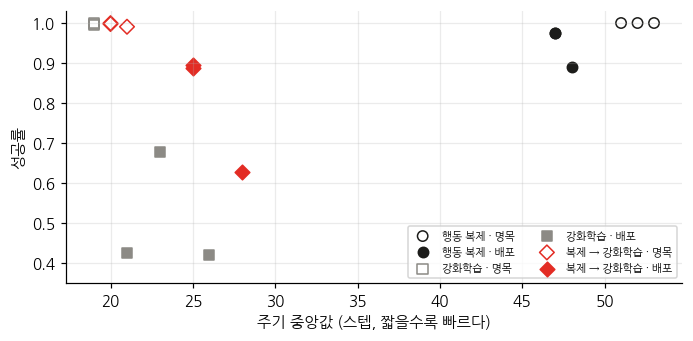

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for k, col, mk in zip(CAND, (INK, GREY, RED), "osD"):
    for c, fill in (("명목", "none"), ("배포", col)):
        v = RES[(k, c)]
        ax.scatter([x[1] for x in v], [x[0] for x in v], marker=mk,
                   s=46, facecolors=fill, edgecolors=col,
                   label=f"{k} · {c}")
ax.set_xlabel("주기 중앙값 (스텝, 짧을수록 빠르다)")
ax.set_ylabel("성공률")
ax.set_ylim(.35, 1.03)
ax.legend(fontsize=7, loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

## 기준선을 고정한다

3부의 나머지 두 장과 4~6부가 비교할 **두 수**를 정한다. 행동 복제와 강화학습 각각에서 시드 0의 정책을 저장하고, 세 시드의 평균과 범위를 함께 적는다. 이어 학습 정책은 기준선으로 삼지 않는다 — 이유는 앞 표에 있다.

In [12]:
os.makedirs("policy", exist_ok=True)
torch.save(NETS[("행동 복제", 0)], "policy/bc_v1.pt")
torch.save(NETS[("강화학습", 0)], "policy/rl_v1.pt")
BASE = {}
for k, key in (("행동 복제", "bc_v1"), ("강화학습", "rl_v1")):
    BASE[key] = {}
    for c in COND:
        sr = [x[0] for x in RES[(k, c)]]
        cy = [x[1] for x in RES[(k, c)]]
        BASE[key][c] = {"mean": round(float(np.mean(sr)), 3),
                        "range": [round(float(min(sr)), 3),
                                  round(float(max(sr)), 3)],
                        "cycle": round(float(np.mean(cy)), 1)}
BASE["norm"] = "data/cell_v1/meta/stats.json"
BASE["eval"] = "mean action, 150 cells x 330 steps, 3 seeds"
with open("policy/baseline.json", "w") as f:
    json.dump(BASE, f, ensure_ascii=False, indent=1)
save_log("report/ch07_log.csv", LOG)
print(json.dumps(BASE, ensure_ascii=False, indent=1))
print()
print("남긴 산출물")
print("  policy/bc_v1.pt        행동 복제 기준 정책 (시드 0)")
print("  policy/rl_v1.pt        강화학습 기준 정책 (시드 0)")
print("  policy/baseline.json   두 기준선의 수")
print(f"  report/ch07_log.csv    판별 로그 {len(LOG):,}줄")

{
 "bc_v1": {
  "명목": {
   "mean": 1.0,
   "range": [
    1.0,
    1.0
   ],
   "cycle": 52.0
  },
  "배포": {
   "mean": 0.947,
   "range": [
    0.891,
    0.975
   ],
   "cycle": 47.3
  }
 },
 "rl_v1": {
  "명목": {
   "mean": 0.997,
   "range": [
    0.995,
    1.0
   ],
   "cycle": 19.0
  },
  "배포": {
   "mean": 0.508,
   "range": [
    0.421,
    0.678
   ],
   "cycle": 23.3
  }
 },
 "norm": "data/cell_v1/meta/stats.json",
 "eval": "mean action, 150 cells x 330 steps, 3 seeds"
}

남긴 산출물
  policy/bc_v1.pt        행동 복제 기준 정책 (시드 0)
  policy/rl_v1.pt        강화학습 기준 정책 (시드 0)
  policy/baseline.json   두 기준선의 수
  report/ch07_log.csv    판별 로그 24,861줄


## 정리

**복제는 성공률에서, 강화학습은 주기에서 이긴다.** 배포 성공률은 복제 0.947, 강화학습 0.508이다. 주기는 강화학습이 19스텝으로 복제(52)의 절반 아래다.

**전문가가 없는 축에서만 강화학습이 무언가를 더한다.** 복제로 시작해 강화학습으로 이어 가면 주기가 강화학습만큼 짧아지지만, 배포 성공률이 0.947에서 0.804로 내려간다. 빨라진 대가를 지연 앞에서 치른다.

**기준선은 둘이다.** 행동 복제(`policy/bc_v1.pt`)와 강화학습(`policy/rl_v1.pt`)의 수를 `policy/baseline.json` 에 적었다. 8·9장은 복제를 손보고, 4부는 두 기준선이 어느 갭에 약한지를 잰다.